# Financial Risk Analysis with Python

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [191]:
morgan_df = pd.read_csv("morgan_stanely.csv")

## Task 1: Data Cleaning and Formatting

In [192]:
morgan_df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,06-01-2023,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,17-02-2023,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,13-09-2023,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,28-05-2024,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,12-05-2023,77104.456470,57425.69930,1.042441,393,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,01-01-2024,74309.497130,61659.15894,0.425553,372,23
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,12-05-2023,45859.598950,103267.73470,0.642004,401,104
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,22-03-2024,458.484909,59361.15542,0.410000,667,139
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,21-03-2024,31344.178850,168048.03330,0.546988,407,30


In [193]:
morgan_df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,06-01-2023,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,17-02-2023,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,13-09-2023,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,28-05-2024,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,12-05-2023,77104.456470,57425.69930,1.042441,393,10


In [194]:
morgan_df.tail()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,01-01-2024,74309.497130,61659.15894,0.425553,372,23
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,12-05-2023,45859.598950,103267.73470,0.642004,401,104
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,22-03-2024,458.484909,59361.15542,0.410000,667,139
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,21-03-2024,31344.178850,168048.03330,0.546988,407,30
799,71,CUST8028,ACC90887,Credit,Payment,Personal Loan,Firm C,West,Manager 3,29-01-2024,57594.199810,138865.93960,0.419232,529,65


In [195]:
morgan_df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [196]:
morgan_df['TransactionDate'] = pd.to_datetime(
    morgan_df['TransactionDate'],
    dayfirst=True,
    errors='coerce'
)

In [197]:
morgan_df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,2024-01-01,74309.497130,61659.15894,0.425553,372,23
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,2023-05-12,45859.598950,103267.73470,0.642004,401,104
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,2024-03-22,458.484909,59361.15542,0.410000,667,139
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,31344.178850,168048.03330,0.546988,407,30


In [198]:
morgan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

## Task 2: Descriptive Transactional Analysis

###  Task 2.1 : Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.

In [199]:
morgan_df['TrsnDirection'] = morgan_df['TransactionType'].map({'Deposit':'Credit','Withdrawal':'Debit','Transfer':'Debit','Payment':'Debit'})

In [200]:
morgan_df['TrsnDirection']

0       Debit
1       Debit
2       Debit
3       Debit
4      Credit
        ...  
795     Debit
796     Debit
797     Debit
798     Debit
799     Debit
Name: TrsnDirection, Length: 800, dtype: object

In [201]:
morgan_df['Month'] = morgan_df['TransactionDate'].dt.month

In [202]:
morgan_df['Year'] = morgan_df['TransactionDate'].dt.year

In [203]:
morgan_df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,TrsnDirection,Month,Year
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13,Debit,1,2023
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18,Debit,2,2023
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25,Debit,9,2023
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13,Debit,5,2024
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10,Credit,5,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,2024-01-01,74309.497130,61659.15894,0.425553,372,23,Debit,1,2024
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,2023-05-12,45859.598950,103267.73470,0.642004,401,104,Debit,5,2023
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,2024-03-22,458.484909,59361.15542,0.410000,667,139,Debit,3,2024
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,31344.178850,168048.03330,0.546988,407,30,Debit,3,2024


In [204]:
Monthly_summary = morgan_df.pivot_table(values = 'TransactionAmount',
                                        index = ['Month'],
                                        columns = ['TrsnDirection'],
                                        aggfunc = 'sum',
                                        fill_value = 0)

In [205]:
Monthly_summary['NetVolume'] = Monthly_summary['Credit'] - Monthly_summary['Debit']
Monthly_summary

TrsnDirection,Credit,Debit,NetVolume
Month,,,
1,1.321995e+06,3.345573e+06,-2.023578e+06
2,1.231897e+06,4.040010e+06,-2.808113e+06
3,1.142629e+06,3.580992e+06,-2.438363e+06
4,1.196326e+06,3.811147e+06,-2.614820e+06
5,1.205283e+06,3.760798e+06,-2.555514e+06
6,7.402068e+05,2.957157e+06,-2.216950e+06
7,7.760727e+05,1.706737e+06,-9.306644e+05
8,4.737014e+05,1.305793e+06,-8.320915e+05
9,8.639821e+05,1.857039e+06,-9.930567e+05


In [206]:
Yearly_summary = morgan_df.pivot_table(values = 'TransactionAmount',
                                       index = ['Year'],
                                       columns = 'TrsnDirection',
                                       aggfunc = 'sum',
                                       fill_value = 0)

In [207]:
Yearly_summary['NetVolume'] = Yearly_summary['Credit']-Yearly_summary['Debit']
Yearly_summary

TrsnDirection,Credit,Debit,NetVolume
Year,,,
2023,7.727269e+06,2.301558e+07,-1.528831e+07
2024,3.249579e+06,1.016349e+07,-6.913907e+06


### Task 2.2 : Plot trends in total credits vs. debits over time.

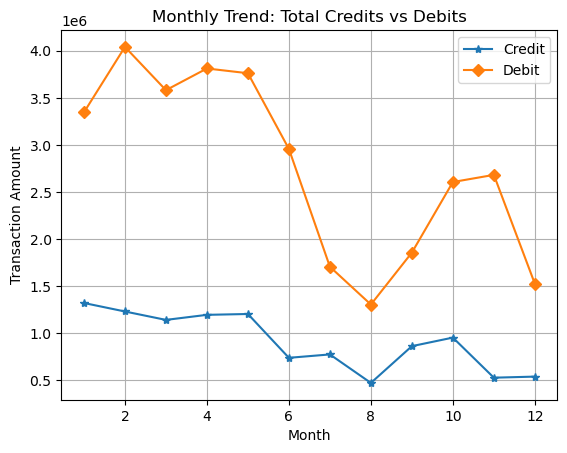

In [208]:
plt.plot(Monthly_summary.index ,Monthly_summary['Credit'],marker = '*',label = 'Credit')
plt.plot(Monthly_summary.index ,Monthly_summary['Debit'],marker = 'D',label = 'Debit')
plt.title('Monthly Trend: Total Credits vs Debits')
plt.xlabel('Month')
plt.ylabel('Transaction Amount')
plt.legend()
plt.grid()
plt.show()

### Task 2.3 : Identify top and bottom performing accounts based on net inflow.

In [209]:
Account_summary = morgan_df.pivot_table(values = 'TransactionAmount',
                                        index = 'AccountID',
                                        columns = 'TrsnDirection',
                                        aggfunc = 'sum',
                                        fill_value = 0)
Account_summary

TrsnDirection,Credit,Debit
AccountID,,
ACC10117,52336.34278,547292.394920
ACC10996,254968.10439,251778.053670
ACC11062,0.00000,247384.209240
ACC11188,0.00000,127634.925880
ACC11285,0.00000,169318.969530
...,...,...
ACC96868,105119.41035,212439.160530
ACC97411,48958.41071,255284.144150
ACC99117,0.00000,116276.799160


In [210]:
# net inflow of top 5 accounts
Account_summary['Net Inflow'] = Account_summary['Credit']-Account_summary['Debit']

In [211]:
top_account = Account_summary.sort_values(by = 'Net Inflow',ascending = False).head()
top_account

TrsnDirection,Credit,Debit,Net Inflow
AccountID,,,
ACC38559,219919.516230,24073.272256,195846.243974
ACC57700,250121.858500,78718.715500,171403.143000
ACC31539,150937.249760,21990.050000,128947.199760
ACC51971,115097.311765,0.000000,115097.311765
ACC18177,174360.269780,71865.548810,102494.720970


In [212]:
bottom_account = Account_summary.sort_values(by = 'Net Inflow',ascending = False).tail()
bottom_account

TrsnDirection,Credit,Debit,Net Inflow
AccountID,,,
ACC19178,62859.62790,491586.39945,-428726.77155
ACC88449,66198.87121,524857.86232,-458658.99111
ACC51009,39011.23849,532634.18963,-493622.95114
ACC10117,52336.34278,547292.39492,-494956.05214
ACC61926,60238.27980,753412.31995,-693174.04015


### Task 2.4 : Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.

In [213]:
morgan_df1 = morgan_df.sort_values(by = ['AccountID','TransactionDate'])

In [214]:
morgan_df1

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,TrsnDirection,Month,Year
58,72,CUST1498,ACC10117,Current,Deposit,Mutual Fund,Firm D,North,Manager 1,2023-01-30,52336.34278,46657.21790,0.227450,659,16,Credit,1,2023
555,173,CUST2067,ACC10117,Current,Transfer,Personal Loan,Firm D,East,Manager 1,2023-04-30,77018.97098,180539.28770,0.396153,393,45,Debit,4,2023
509,127,CUST9528,ACC10117,Savings,Transfer,Mutual Fund,Firm C,East,Manager 4,2023-06-20,65805.20213,80204.67302,0.457247,618,181,Debit,6,2023
696,180,CUST2541,ACC10117,Current,Withdrawal,Credit Card,Firm A,Central,Manager 4,2023-07-14,89395.76266,70489.10944,0.185195,494,223,Debit,7,2023
727,114,CUST8091,ACC10117,Savings,Withdrawal,Credit Card,Firm A,South,Manager 3,2023-08-04,-18353.15647,99972.73002,-0.010665,619,225,Debit,8,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518,50,CUST4625,ACC99549,Credit,Transfer,Personal Loan,Firm E,North,Manager 3,2023-06-06,72499.16252,105166.59750,0.486469,360,50,Debit,6,2023
231,124,CUST7855,ACC99549,Current,Transfer,Credit Card,Firm D,West,Manager 1,2023-07-19,82091.03853,110405.27400,0.686125,529,83,Debit,7,2023
563,142,CUST4461,ACC99549,Credit,Deposit,Savings Account,Firm A,North,Manager 2,2024-02-04,77101.58761,110685.58450,0.644535,715,174,Credit,2,2024
67,136,CUST4669,ACC99549,Current,Transfer,Credit Card,Firm B,Central,Manager 3,2024-02-21,97870.57220,70920.37000,0.296737,589,9,Debit,2,2024


In [215]:
morgan_df['GapDays'] = (morgan_df.groupby('AccountID')['TransactionDate'].diff().dt.days)

In [216]:
morgan_df['GapDays'] = (morgan_df['GapDays'].fillna(0))

In [217]:
morgan_df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,TrsnDirection,Month,Year,GapDays
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13,Debit,1,2023,0.0
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18,Debit,2,2023,0.0
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25,Debit,9,2023,0.0
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13,Debit,5,2024,0.0
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10,Credit,5,2023,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,2024-01-01,74309.497130,61659.15894,0.425553,372,23,Debit,1,2024,-110.0
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,2023-05-12,45859.598950,103267.73470,0.642004,401,104,Debit,5,2023,-201.0
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,2024-03-22,458.484909,59361.15542,0.410000,667,139,Debit,3,2024,-30.0
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,31344.178850,168048.03330,0.546988,407,30,Debit,3,2024,294.0


In [218]:
morgan_df['DormantFlag'] = morgan_df['GapDays']>=60

In [219]:
morgan_df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,TrsnDirection,Month,Year,GapDays,DormantFlag
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13,Debit,1,2023,0.0,False
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18,Debit,2,2023,0.0,False
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25,Debit,9,2023,0.0,False
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13,Debit,5,2024,0.0,False
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10,Credit,5,2023,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,2024-01-01,74309.497130,61659.15894,0.425553,372,23,Debit,1,2024,-110.0,False
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,2023-05-12,45859.598950,103267.73470,0.642004,401,104,Debit,5,2023,-201.0,False
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,2024-03-22,458.484909,59361.15542,0.410000,667,139,Debit,3,2024,-30.0,False
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,31344.178850,168048.03330,0.546988,407,30,Debit,3,2024,294.0,True


In [220]:
dormant_accounts = (morgan_df.groupby('AccountID')['DormantFlag'].any().reset_index())

In [221]:
dormant_accounts.head()

,AccountID,DormantFlag
0,ACC10117,True
1,ACC10996,True
2,ACC11062,True
3,ACC11188,False
4,ACC11285,True


## Task 3: Customer Profile Building

### Task 3.1 : Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.

In [222]:
Acc_Txn_count = (morgan_df.groupby('AccountID').size().reset_index(name = 'Txn_Count'))

In [223]:
def Activity_level(Txn_Count):
    if Txn_Count>15:
        return "High"
    elif 5<= Txn_Count<=15:
        return "Medium"
    else:
        return "Low"

Acc_Txn_count['Activity_Level'] = Acc_Txn_count['Txn_Count'].apply(Activity_level)

In [224]:
Acc_Txn_count


,AccountID,Txn_Count,Activity_Level
0,ACC10117,9,Medium
1,ACC10996,8,Medium
2,ACC11062,4,Low
3,ACC11188,2,Low
4,ACC11285,5,Medium
...,...,...,...
184,ACC96868,5,Medium
185,ACC97411,4,Low
186,ACC99117,2,Low
187,ACC99409,2,Low


In [225]:
morgan_df = morgan_df.merge(
    Acc_Txn_count[['AccountID', 'Activity_Level']],
    on='AccountID',
    how='left'
)

In [226]:
morgan_df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,AccountBalance,RiskScore,CreditRating,TenureMonths,TrsnDirection,Month,Year,GapDays,DormantFlag,Activity_Level
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,...,40843.56193,0.330474,484,13,Debit,1,2023,0.0,False,Medium
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,...,61183.03953,0.089688,836,18,Debit,2,2023,0.0,False,Medium
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,...,85460.13405,0.340010,451,25,Debit,9,2023,0.0,False,Low
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,...,100525.35900,0.605383,487,13,Debit,5,2024,0.0,False,Medium
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,...,57425.69930,1.042441,393,10,Credit,5,2023,0.0,False,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,2024-01-01,...,61659.15894,0.425553,372,23,Debit,1,2024,-110.0,False,Low
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,2023-05-12,...,103267.73470,0.642004,401,104,Debit,5,2023,-201.0,False,Medium
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,2024-03-22,...,59361.15542,0.410000,667,139,Debit,3,2024,-30.0,False,Low
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,...,168048.03330,0.546988,407,30,Debit,3,2024,294.0,True,Medium


### Task 3.2 : Segment customers by average balance and transaction volume.

In [227]:
customer_seg = (
    morgan_df
    .groupby('CustomerID')
    .agg(
        AvgBalance=('AccountBalance', 'mean'),
        AvgTxnVolume=('TransactionAmount', 'mean')
    )
    .reset_index()
)

In [228]:
balance_q25 = customer_seg['AvgBalance'].quantile(0.25)
balance_q75 = customer_seg['AvgBalance'].quantile(0.75)

txn_q25 = customer_seg['AvgTxnVolume'].quantile(0.25)
txn_q75 = customer_seg['AvgTxnVolume'].quantile(0.75)


In [229]:
def balance_segment(val):
    if val >= balance_q75:
        return 'High Bal'
    elif val >= balance_q25:
        return 'Medium Bal'
    else:
        return 'Low Bal'

customer_seg['BalanceSegment'] = customer_seg['AvgBalance'].apply(balance_segment)


In [230]:
customer_seg

,CustomerID,AvgBalance,AvgTxnVolume,BalanceSegment
0,CUST1042,76679.924205,48431.750777,Medium Bal
1,CUST1114,72400.226331,58538.614916,Medium Bal
2,CUST1121,71921.285297,46674.809000,Medium Bal
3,CUST1189,40568.418580,39464.729818,Low Bal
4,CUST1223,59819.745227,68822.133490,Medium Bal
...,...,...,...,...
175,CUST9683,65201.208387,69590.468392,Medium Bal
176,CUST9731,85314.413970,34053.361667,High Bal
177,CUST9754,38125.179054,70994.425413,Low Bal
178,CUST9843,93886.366000,33516.157140,High Bal


In [231]:
def txn_segment(val):
    if val >= txn_q75:
        return 'High Vol'
    elif val >= txn_q25:
        return 'Medium Vol'
    else:
        return 'Low Vol'

In [232]:
customer_seg['TxnVolumeSegment'] = customer_seg['AvgTxnVolume'].apply(txn_segment)


In [233]:
customer_seg

,CustomerID,AvgBalance,AvgTxnVolume,BalanceSegment,TxnVolumeSegment
0,CUST1042,76679.924205,48431.750777,Medium Bal,Medium Vol
1,CUST1114,72400.226331,58538.614916,Medium Bal,Medium Vol
2,CUST1121,71921.285297,46674.809000,Medium Bal,Medium Vol
3,CUST1189,40568.418580,39464.729818,Low Bal,Low Vol
4,CUST1223,59819.745227,68822.133490,Medium Bal,High Vol
...,...,...,...,...,...
175,CUST9683,65201.208387,69590.468392,Medium Bal,High Vol
176,CUST9731,85314.413970,34053.361667,High Bal,Low Vol
177,CUST9754,38125.179054,70994.425413,Low Bal,High Vol
178,CUST9843,93886.366000,33516.157140,High Bal,Low Vol


In [234]:
morgan_df = morgan_df.merge(customer_seg[['CustomerID','BalanceSegment','TxnVolumeSegment']],
                            on = 'CustomerID',
                            how = 'left')

In [235]:
morgan_df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,CreditRating,TenureMonths,TrsnDirection,Month,Year,GapDays,DormantFlag,Activity_Level,BalanceSegment,TxnVolumeSegment
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,...,484,13,Debit,1,2023,0.0,False,Medium,Medium Bal,High Vol
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,...,836,18,Debit,2,2023,0.0,False,Medium,Low Bal,Low Vol
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,...,451,25,Debit,9,2023,0.0,False,Low,Medium Bal,Low Vol
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,...,487,13,Debit,5,2024,0.0,False,Medium,High Bal,Medium Vol
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,...,393,10,Credit,5,2023,0.0,False,Medium,Medium Bal,High Vol
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,2024-01-01,...,372,23,Debit,1,2024,-110.0,False,Low,Medium Bal,High Vol
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,2023-05-12,...,401,104,Debit,5,2023,-201.0,False,Medium,High Bal,Medium Vol
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,2024-03-22,...,667,139,Debit,3,2024,-30.0,False,Low,Medium Bal,Low Vol
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,...,407,30,Debit,3,2024,294.0,True,Medium,High Bal,Medium Vol


### Task 3.3 : Create profiles for: High-net inflow accounts, High-frequency low-balance accounts, Accounts with negative or near-zero balances

In [236]:
acc_inflow = morgan_df.pivot_table(
    values = 'TransactionAmount',
    index = 'AccountID',
    columns = 'TrsnDirection',
    aggfunc = 'sum',
    fill_value = '0')

In [237]:
acc_inflow

TrsnDirection,Credit,Debit
AccountID,,
ACC10117,52336.34278,547292.39492
ACC10996,254968.10439,251778.05367
ACC11062,0,247384.20924
ACC11188,0,127634.92588
ACC11285,0,169318.96953
...,...,...
ACC96868,105119.41035,212439.16053
ACC97411,48958.41071,255284.14415
ACC99117,0,116276.79916


In [238]:
acc_inflow['Credit'] = acc_inflow['Credit'].astype(float)
acc_inflow['Debit'] = acc_inflow['Debit'].astype(float)
acc_inflow['Net_Inflow'] = acc_inflow['Credit']-acc_inflow['Debit']
acc_inflow

TrsnDirection,Credit,Debit,Net_Inflow
AccountID,,,
ACC10117,52336.34278,547292.394920,-494956.052140
ACC10996,254968.10439,251778.053670,3190.050720
ACC11062,0.00000,247384.209240,-247384.209240
ACC11188,0.00000,127634.925880,-127634.925880
ACC11285,0.00000,169318.969530,-169318.969530
...,...,...,...
ACC96868,105119.41035,212439.160530,-107319.750180
ACC97411,48958.41071,255284.144150,-206325.733440
ACC99117,0.00000,116276.799160,-116276.799160


In [239]:
# Threshold for high net inflow (top 25%)
net_inflow_threshold = acc_inflow['Net_Inflow'].quantile(0.75)


In [240]:
# High-net inflow accounts
high_net_inflow_accounts = acc_inflow[
    acc_inflow['Net_Inflow'] >= net_inflow_threshold
].reset_index()
high_net_inflow_accounts

TrsnDirection,AccountID,Credit,Debit,Net_Inflow
0,ACC10996,254968.104390,251778.053670,3190.050720
1,ACC12334,74852.576147,0.000000,74852.576147
2,ACC15359,78950.074540,77126.999950,1823.074590
3,ACC15925,71686.400650,0.000000,71686.400650
4,ACC18177,174360.269780,71865.548810,102494.720970
5,ACC21429,125891.590620,90807.046140,35084.544480
6,ACC21719,55877.799200,69881.512620,-14003.713420
7,ACC21878,69626.633210,71089.496420,-1462.863210
8,ACC22255,24026.762470,4284.251081,19742.511389
9,ACC24981,33128.677400,41745.035950,-8616.358550


In [241]:
# Transaction frequency per account
txn_freq = morgan_df.groupby('AccountID').size().reset_index(name='TxnCount')

In [242]:
# Average balance per account
avg_balance = morgan_df.groupby('AccountID')['AccountBalance'].mean().reset_index(name='AvgBalance')

In [243]:
# Merge
account_behavior = txn_freq.merge(avg_balance, on='AccountID')

In [244]:
account_behavior

,AccountID,TxnCount,AvgBalance
0,ACC10117,9,94082.590727
1,ACC10996,8,72517.761136
2,ACC11062,4,73541.328302
3,ACC11188,2,51359.039950
4,ACC11285,5,79923.619870
...,...,...,...
184,ACC96868,5,73833.947050
185,ACC97411,4,32190.912745
186,ACC99117,2,110239.787525
187,ACC99409,2,33525.389300


In [245]:
# Thresholds
high_freq_threshold = account_behavior['TxnCount'].quantile(0.75)
low_balance_threshold = account_behavior['AvgBalance'].quantile(0.25)

In [246]:
# High-frequency low-balance accounts
high_freq_low_balance_accounts = account_behavior[
    (account_behavior['TxnCount'] >= high_freq_threshold) &
    (account_behavior['AvgBalance'] <= low_balance_threshold)
]
high_freq_low_balance_accounts

,AccountID,TxnCount,AvgBalance
11,ACC15671,6,54565.019303
18,ACC18177,6,58248.054195
32,ACC24508,7,57275.485464
47,ACC29231,7,54530.479503
98,ACC50817,7,59021.066076
105,ACC53466,6,52903.763152


In [247]:
#Accounts with negative or near-zero balances
negative_or_low_balance_accounts = avg_balance[
    avg_balance['AvgBalance'] <= 10000
]
negative_or_low_balance_accounts

,AccountID,AvgBalance
34,ACC24981,9581.457157
38,ACC26940,7017.436865


## Task 4: Financial Risk Identification

### Task 4.1 : Track accounts with frequent large withdrawals or overdrafts.

In [248]:
# Consider only Debit transactions
withdrawals = morgan_df[morgan_df['TrsnDirection'] == 'Debit']

In [249]:
# Threshold for large withdrawal (top 25%)
large_withdrawal_threshold = withdrawals['TransactionAmount'].quantile(0.75)

In [250]:
large_withdrawals = withdrawals[
    withdrawals['TransactionAmount'] >= large_withdrawal_threshold
]

In [251]:
# Track Accounts with Frequent Large Withdrawals
frequent_large_withdrawals = (
    large_withdrawals
    .groupby('AccountID')
    .size()
    .reset_index(name='LargeWithdrawalCount')
)
# Define frequent threshold
frequent_large_withdrawals = frequent_large_withdrawals[
    frequent_large_withdrawals['LargeWithdrawalCount'] > 5]
frequent_large_withdrawals 


,AccountID,LargeWithdrawalCount
61,ACC61926,6


In [252]:
# Identify Overdraft Accounts
overdraft_accounts = morgan_df[
    morgan_df['AccountBalance'] <= 0
][['AccountID']].drop_duplicates()
overdraft_accounts

,AccountID
158,ACC26940
224,ACC48501
237,ACC89098
253,ACC34431
350,ACC17688
391,ACC18177
398,ACC60432
401,ACC77773
416,ACC32212
417,ACC50817


In [253]:
risky_accounts = pd.merge(
    frequent_large_withdrawals,
    overdraft_accounts,
    on='AccountID',
    how='outer',
    indicator=True
)

In [254]:
risky_accounts['RiskType'] = risky_accounts['_merge'].map({
    'left_only': 'Frequent Large Withdrawals',
    'right_only': 'Overdraft Risk',
    'both': 'High Risk (Withdrawals + Overdraft)'
})

In [255]:
risky_accounts[['AccountID', 'RiskType']]

,AccountID,RiskType
0,ACC11837,Overdraft Risk
1,ACC17688,Overdraft Risk
2,ACC18177,Overdraft Risk
3,ACC19156,Overdraft Risk
4,ACC26940,Overdraft Risk
5,ACC32212,Overdraft Risk
6,ACC34431,Overdraft Risk
7,ACC39529,Overdraft Risk
8,ACC48501,Overdraft Risk
9,ACC49774,Overdraft Risk


In [256]:
risky_accounts

,AccountID,LargeWithdrawalCount,_merge,RiskType
0,ACC11837,NaN,right_only,Overdraft Risk
1,ACC17688,NaN,right_only,Overdraft Risk
2,ACC18177,NaN,right_only,Overdraft Risk
3,ACC19156,NaN,right_only,Overdraft Risk
4,ACC26940,NaN,right_only,Overdraft Risk
5,ACC32212,NaN,right_only,Overdraft Risk
6,ACC34431,NaN,right_only,Overdraft Risk
7,ACC39529,NaN,right_only,Overdraft Risk
8,ACC48501,NaN,right_only,Overdraft Risk
9,ACC49774,NaN,right_only,Overdraft Risk


### Task 4.2 : Calculate balance volatility using standard deviation or coefficient of variation.

In [257]:
# Calculate Balance Volatility using Standard Deviation
balance_volatility_std = (
    morgan_df
    .groupby('AccountID')['AccountBalance']
    .std()
    .reset_index(name='BalanceStdDev')
)
balance_volatility_std

,AccountID,BalanceStdDev
0,ACC10117,38036.539989
1,ACC10996,30036.385595
2,ACC11062,33831.704345
3,ACC11188,9067.866694
4,ACC11285,25590.622179
...,...,...
184,ACC96868,32045.151315
185,ACC97411,68179.288932
186,ACC99117,35043.722015
187,ACC99409,16361.048144


In [258]:
#Calculates Balance Volatility using CV because standard deviation alone can be misleading
# Mean balance per account
avg_balance = (
    morgan_df
    .groupby('AccountID')['AccountBalance']
    .mean()
    .reset_index(name='AvgBalance')
)

In [259]:
# Merge with std deviation
balance_volatility = balance_volatility_std.merge(
    avg_balance,
    on='AccountID'
)

In [260]:
# Calculate coefficient of variation
balance_volatility['BalanceCV'] = (
    balance_volatility['BalanceStdDev'] /
    balance_volatility['AvgBalance']
)

In [261]:
balance_volatility['BalanceCV'] = (
    balance_volatility['BalanceCV']
    .replace([np.inf, -np.inf], np.nan)
)
balance_volatility

,AccountID,BalanceStdDev,AvgBalance,BalanceCV
0,ACC10117,38036.539989,94082.590727,0.404289
1,ACC10996,30036.385595,72517.761136,0.414194
2,ACC11062,33831.704345,73541.328302,0.460037
3,ACC11188,9067.866694,51359.039950,0.176558
4,ACC11285,25590.622179,79923.619870,0.320188
...,...,...,...,...
184,ACC96868,32045.151315,73833.947050,0.434017
185,ACC97411,68179.288932,32190.912745,2.117967
186,ACC99117,35043.722015,110239.787525,0.317886
187,ACC99409,16361.048144,33525.389300,0.488020


### Task 4.3 : Use IQR or z-score methods to detect anomalies.

In [262]:
Q1 = morgan_df['TransactionAmount'].quantile(0.25)
Q3 = morgan_df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_anomalies = morgan_df[
    (morgan_df['TransactionAmount'] < lower_bound) |
    (morgan_df['TransactionAmount'] > upper_bound)
]
iqr_anomalies

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,CreditRating,TenureMonths,TrsnDirection,Month,Year,GapDays,DormantFlag,Activity_Level,BalanceSegment,TxnVolumeSegment
9,13,CUST2805,ACC19178,Credit,Payment,Credit Card,Firm D,West,Manager 3,2024-02-17,...,747,126,Debit,2,2024,0.0,False,Medium,Low Bal,High Vol
161,52,CUST4258,ACC35419,Loan,Transfer,Personal Loan,Firm B,Central,Manager 1,2023-11-07,...,745,29,Debit,11,2023,210.0,True,Low,Medium Bal,Low Vol
370,92,CUST6526,ACC77533,Loan,Transfer,Mutual Fund,Firm D,West,Manager 3,2024-02-17,...,841,62,Debit,2,2024,0.0,False,Low,Medium Bal,High Vol
525,131,CUST4769,ACC92104,Current,Deposit,Mutual Fund,Firm B,East,Manager 1,2024-01-17,...,364,231,Credit,1,2024,59.0,False,Low,Medium Bal,High Vol
533,47,CUST7098,ACC23736,Loan,Payment,Home Loan,Firm E,West,Manager 3,2023-09-28,...,624,19,Debit,9,2023,127.0,True,Medium,Low Bal,High Vol


### Task 4.4 : Highlight customers with irregular or suspicious transaction behavior.

In [263]:
# to identify Customers with Anomalous Transactions (IQR)
anomaly_customers = iqr_anomalies['CustomerID'].unique()

# to identify Customers with Frequent Large Withdrawals
frequent_withdrawal_customers = frequent_large_withdrawals['AccountID'].unique()

frequent_withdrawal_customers = (
    morgan_df[morgan_df['AccountID'].isin(frequent_withdrawal_customers)]
    ['CustomerID']
    .unique())



In [264]:
# this identifies Customers with Low or Negative Balances
low_balance_threshold = avg_balance['AvgBalance'].quantile(0.25)

low_balance_accounts = avg_balance[
    avg_balance['AvgBalance'] <= low_balance_threshold
]['AccountID']

In [265]:
low_balance_customers = (
    morgan_df[morgan_df['AccountID'].isin(low_balance_accounts)]
    ['CustomerID']
    .unique()
)


In [266]:
high_volatility_threshold = balance_volatility['BalanceCV'].quantile(0.75)

high_volatility_customers = balance_volatility[
    balance_volatility['BalanceCV'] >= high_volatility_threshold
]['AccountID']


In [267]:
high_volatility_customers = (
    morgan_df[morgan_df['AccountID'].isin(high_volatility_customers)]
    ['CustomerID']
    .unique()
)


In [268]:
suspicious_customers = set(
    anomaly_customers
).union(
    frequent_withdrawal_customers,
    low_balance_customers,
    high_volatility_customers
)

suspicious_customers = pd.DataFrame(
    suspicious_customers,
    columns=['CustomerID']
)
suspicious_customers

,CustomerID
0,CUST6292
1,CUST1569
2,CUST5320
3,CUST4258
4,CUST3602
...,...
137,CUST6351
138,CUST2188
139,CUST2349
140,CUST5574


## Task 5: Visualisation

### Task 5.1 : Conduct extensive exploratory data analysis with attractive visualizations for your findings

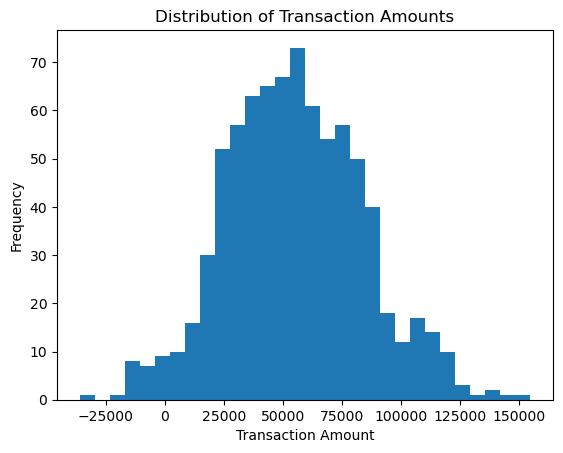

In [269]:
# To understand how transaction amounts are spread and identify extreme values.
plt.figure()
plt.hist(morgan_df['TransactionAmount'], bins=30)
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Amounts')
plt.show()


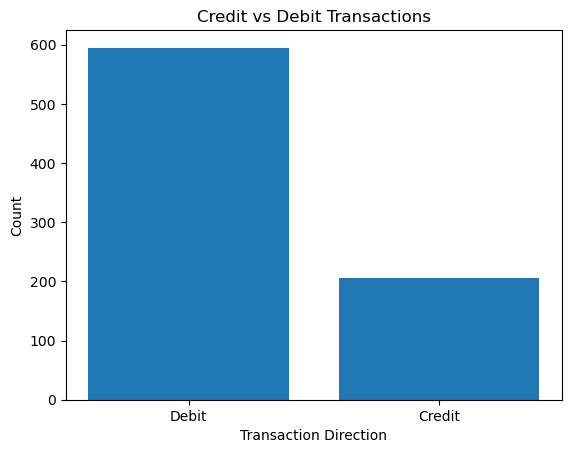

In [270]:
# To compare money inflow vs outflow activity.
txn_counts = morgan_df['TrsnDirection'].value_counts()
plt.figure()
plt.bar(txn_counts.index, txn_counts.values)
plt.xlabel('Transaction Direction')
plt.ylabel('Count')
plt.title('Credit vs Debit Transactions')
plt.show()


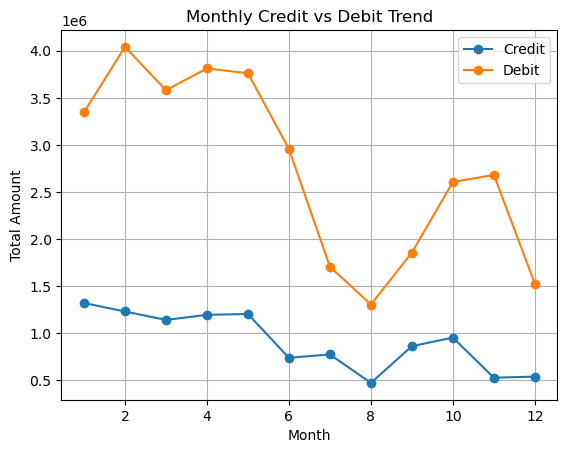

In [271]:
# To analyze cash flow trends over time.
plt.figure()
plt.plot(Monthly_summary.index, Monthly_summary['Credit'], label='Credit',marker = 'o')
plt.plot(Monthly_summary.index, Monthly_summary['Debit'], label='Debit',marker = 'o')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.title('Monthly Credit vs Debit Trend')
plt.legend()
plt.grid()
plt.show()


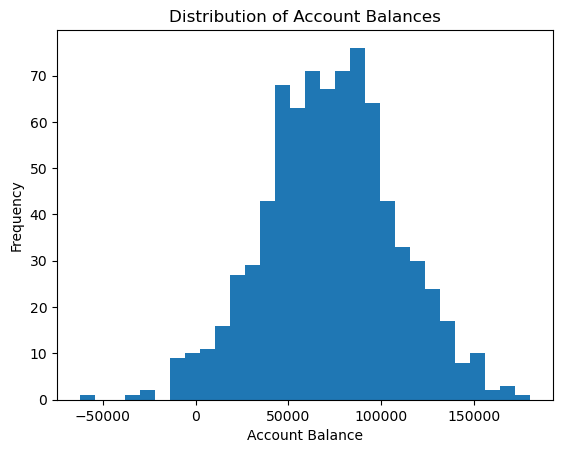

In [272]:
# To assess customer financial stability.
plt.figure()
plt.hist(morgan_df['AccountBalance'], bins=30)
plt.xlabel('Account Balance')
plt.ylabel('Frequency')
plt.title('Distribution of Account Balances')
plt.show()


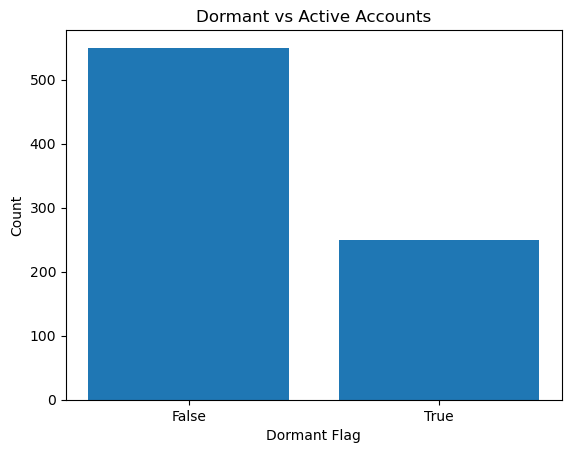

In [273]:
# To understand inactivity patterns.
dormant_counts = morgan_df['DormantFlag'].value_counts()
plt.figure()
plt.bar(dormant_counts.index.astype(str), dormant_counts.values)
plt.xlabel('Dormant Flag')
plt.ylabel('Count')
plt.title('Dormant vs Active Accounts')
plt.show()


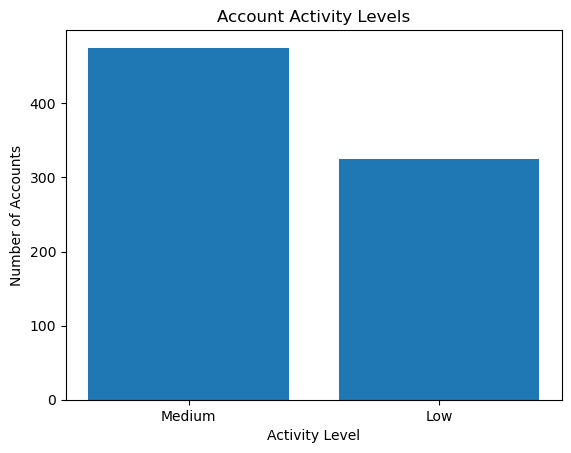

In [274]:
# To measure customer engagement.
activity_counts = morgan_df['Activity_Level'].value_counts()

plt.figure()
plt.bar(activity_counts.index, activity_counts.values)
plt.xlabel('Activity Level')
plt.ylabel('Number of Accounts')
plt.title('Account Activity Levels')
plt.show()


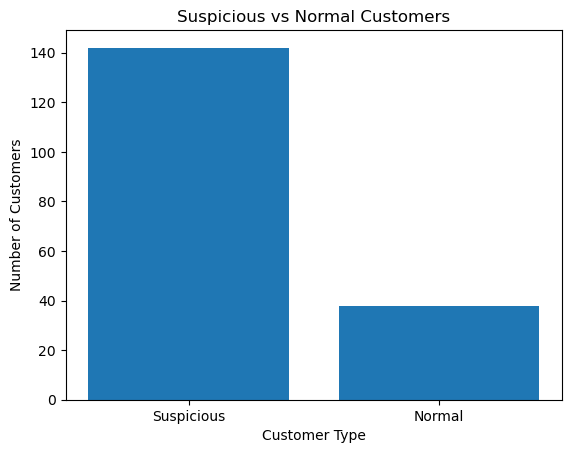

In [275]:
# To quantify risk exposure.
labels = ['Suspicious', 'Normal']
values = [
    suspicious_customers.shape[0],
    morgan_df['CustomerID'].nunique() - suspicious_customers.shape[0]
]

plt.figure()
plt.bar(labels, values)
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.title('Suspicious vs Normal Customers')
plt.show()


## Task 6: Hypothesis Testing

### Task 6.1 : Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.

In [276]:
account_avg_txn = (
    morgan_df
    .groupby('AccountID')['TransactionAmount']
    .mean()
    .reset_index(name='AvgTxnVolume')
)

In [277]:
account_data = avg_balance.merge(
    account_avg_txn,
    on='AccountID'
)


In [278]:
high_volume_threshold = account_data['AvgTxnVolume'].quantile(0.75)
low_volume_threshold = account_data['AvgTxnVolume'].quantile(0.25)

account_data['TxnVolumeGroup'] = 'Medium'

account_data.loc[
    account_data['AvgTxnVolume'] >= high_volume_threshold,
    'TxnVolumeGroup'
] = 'High'

account_data.loc[
    account_data['AvgTxnVolume'] <= low_volume_threshold,
    'TxnVolumeGroup'
] = 'Low'

In [279]:
high_volume_balances = account_data[
    account_data['TxnVolumeGroup'] == 'High'
]['AvgBalance']

low_volume_balances = account_data[
    account_data['TxnVolumeGroup'] == 'Low'
]['AvgBalance']

high_volume_balances.shape, low_volume_balances.shape


((48,), (48,))

In [280]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    high_volume_balances,
    low_volume_balances,
    equal_var=False
)

t_stat, p_value


(0.39880247740201574, 0.6909731113098343)

## Task 6.2 : Conduct hypothesis testing based on segmentation.

In [288]:
# Balance volatility (Coefficient of Variation)
balance_volatility = (
    morgan_df
    .groupby('AccountID')['AccountBalance']
    .agg(['mean', 'std'])
    .reset_index()
)

balance_volatility.columns = ['AccountID', 'AvgBalance', 'BalanceStd']

balance_volatility['BalanceCV'] = (
    balance_volatility['BalanceStd'] / balance_volatility['AvgBalance']
)


In [289]:
activity_level = (
    morgan_df[['AccountID', 'Activity_Level']]
    .drop_duplicates()
)


In [290]:
activity_volatility = activity_level.merge(
    balance_volatility[['AccountID', 'BalanceCV']],
    on='AccountID',
    how='inner'
)


In [291]:
medium = activity_volatility[
    activity_volatility['Activity_Level'] == 'Medium'
]['BalanceCV']

low = activity_volatility[
    activity_volatility['Activity_Level'] == 'Low'
]['BalanceCV']


In [292]:
medium = medium.dropna()
low = low.dropna()


In [293]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    medium,
    low,
    equal_var=False
)

t_stat, p_value


(-0.18625837077418478, 0.8525546339476513)

## Task 7: Video Presentation

### https://www.loom.com/share/ff2c7444418a40538ac0e5fca37b4b9a